In [1]:
# Kaggle already ships albumentations, albucore, timm and cv2. Do NOT add -U:
# upgrading albumentations/albucore pulls a newer numpy on top of the one this
# kernel already has on disk, and the half-swapped install dies on the next
# import with
#   ImportError: cannot import name '_center' from 'numpy._core.umath'
# tifffile (for the 5-band tifs) is installed without -U so pip leaves numpy
# exactly where it is.
%pip install -q tifffile
import numpy, albumentations
print("numpy", numpy.__version__, "| albumentations", albumentations.__version__)

Note: you may need to restart the kernel to use updated packages.
numpy 2.0.2 | albumentations 2.0.8


In [2]:
# ============================================================
# FETCH b-FLAIR-test
# ============================================================
# b-FLAIR-test is a Hugging Face repo, not a Kaggle dataset, so it is cloned
# into /kaggle/working rather than mounted read-only under /kaggle/input.
# ~4.7 GB of LFS content, ~6 minutes on a cold session, and it counts against
# the 20 GB /kaggle/working quota.
#
# INTERNET MUST BE ON for this cell, and for the setup cell further down (timm
# downloads the ImageNet Swin-Tiny weights).
#
# Re-running is a no-op once annotations/ exists, so this cell is cheap on a
# resumed session.

import subprocess
from pathlib import Path

BFLAIR_ROOT = Path("/kaggle/working/b-FLAIR-test")

if (BFLAIR_ROOT / "annotations").is_dir():
    print("already present:", BFLAIR_ROOT)
else:
    subprocess.run(
        [
            "git", "clone",
            "https://huggingface.co/datasets/elliotvincent/b-FLAIR-test",
            str(BFLAIR_ROOT),
        ],
        check=True,
    )

for _sub in ("t1", "t2", "annotations"):
    _count = len(list((BFLAIR_ROOT / _sub).glob("*.tif")))
    print(f"  {_sub:<12}: {_count} tifs")
print("  metadata.json:", (BFLAIR_ROOT / "metadata.json").exists())

Cloning into '/kaggle/working/b-FLAIR-test'...
Updating files: 100% (5198/5198), done.


  t1          : 1730 tifs
  t2          : 1730 tifs
  annotations : 1730 tifs
  metadata.json: True


Filtering content: 100% (5195/5195), 4.65 GiB | 31.13 MiB/s, done.


In [3]:
import os, gc, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import tifffile

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
for _i in range(torch.cuda.device_count()):
    print(f"  cuda:{_i}:", torch.cuda.get_device_name(_i))

Torch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
  cuda:0: Tesla T4
  cuda:1: Tesla T4


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ============================================================
# PATHS -- b-FLAIR-test
# ============================================================
# Flat layout, no splits, ids shared across the three folders:
#
#     b-FLAIR-test/t1/<id>.tif           pre   512x512x5 uint8
#     b-FLAIR-test/t2/<id>.tif           post  512x512x5 uint8
#     b-FLAIR-test/annotations/<id>.tif  mask  512x512   uint8 {0, 255}
#     b-FLAIR-test/metadata.json         {id: {departement, date_t1, ...}}
#
# Two facts that bite if ignored:
#
#   1. The images are FIVE bands (R, G, B, IR, Elevation), so cv2.imread is
#      not usable -- tifffile is. Only bands 0-2 are read; the encoder is a
#      3-channel ImageNet Swin.
#   2. The masks are {0, 255}, unlike ValaisCD's {0, 1}. The reader uses `> 0`,
#      which is right for either.

T1_DIR = BFLAIR_ROOT / "t1"
T2_DIR = BFLAIR_ROOT / "t2"
ANN_DIR = BFLAIR_ROOT / "annotations"
METADATA_PATH = BFLAIR_ROOT / "metadata.json"

for _path in (T1_DIR, T2_DIR, ANN_DIR, METADATA_PATH):
    if not _path.exists():
        raise FileNotFoundError(
            f"{_path} is missing. Run the clone cell above with internet ON."
        )

OUT_DIR = Path("/kaggle/working/bFLAIR_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# NO SPLIT -- FULL EVALUATION SET
# ============================================================
# b-FLAIR-test is an inference-only benchmark: every one of the 1,730 pairs
# is evaluated. There is no train/val/test partition, and therefore no
# threshold is selected here -- the operating point comes from the checkpoint
# itself (chosen on S2Looking val).

BFLAIR_VERSION = "full-1730"


# ============================================================
# EVAL KNOBS
# ============================================================

IMG_SIZE = 512          # b-FLAIR frames are 512x512; the MODEL tile is 256,
                        # so one frame is four tiles. Eval tiles the frame.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device      :", DEVICE)
print("Data root   :", BFLAIR_ROOT)
print("Split       :", BFLAIR_VERSION, "(no split, all pairs evaluated)")
print("Output dir  :", OUT_DIR)


Device      : cuda
Data root   : /kaggle/working/b-FLAIR-test
Split       : full-1730 (no split, all pairs evaluated)
Output dir  : /kaggle/working/bFLAIR_results


In [5]:
import json

# ============================================================
# BUILD THE FULL INDEX -- ALL 1730 PAIRS, NO SPLIT
# ============================================================
# One row per pair, with the same column names the downstream cells expect.
# label1/label2 duplicate `label` purely so cells written against S2Looking's
# new/demolished pair of masks index without a KeyError; b-FLAIR has a single
# binary construction mask and nothing in the QGMamba path reads them.

with open(METADATA_PATH) as _handle:
    BFLAIR_METADATA = json.load(_handle)


def build_full_index():
    rows = []
    dropped = 0

    for stem in sorted(BFLAIR_METADATA, key=lambda s: int(s)):
        image1 = T1_DIR / (stem + ".tif")
        image2 = T2_DIR / (stem + ".tif")
        label = ANN_DIR / (stem + ".tif")

        # A truncated LFS checkout is the realistic failure here; skip rather
        # than blow up deep inside the evaluation loop.
        if not (image1.exists() and image2.exists() and label.exists()):
            dropped += 1
            continue

        rows.append(
            {
                "name": stem + ".tif",
                "departement": str(BFLAIR_METADATA[stem]["departement"]),
                "image1": str(image1),
                "image2": str(image2),
                "label": str(label),
                "label1": str(label),
                "label2": str(label),
            }
        )

    if dropped:
        print("skipped " + str(dropped) + " incomplete pairs")

    if not rows:
        raise RuntimeError("No usable pairs found in " + str(BFLAIR_ROOT))

    return pd.DataFrame(rows)


# ============================================================
# CHANGE STATISTICS
# ============================================================
# Positive pixel count per pair: it is what makes the per-department breakdown
# below and the visualization sampling meaningful. Cached, because it
# re-runs on every cell execution.


def change_stats(df, split, version):
    cache = OUT_DIR / ("bflair_change_" + split + "_" + str(version) + ".csv")

    if cache.exists():
        cached = pd.read_csv(cache)
        if len(cached) == len(df) and (cached["name"] == df["name"]).all():
            return cached["positive"].to_numpy()

    positives = np.zeros(len(df), dtype=np.int64)
    for i, path in enumerate(tqdm(df["label"].tolist(),
                                  desc="scan " + split, leave=False)):
        mask = tifffile.imread(path)
        if mask.ndim == 3:
            mask = mask[..., 0]
        positives[i] = int((mask > 0).sum())

    pd.DataFrame({"name": df["name"], "positive": positives}).to_csv(
        cache, index=False
    )
    return positives


full_df = build_full_index()
full_df["positive"] = change_stats(full_df, "full", BFLAIR_VERSION)

PIXELS_PER_IMAGE = IMG_SIZE * IMG_SIZE

print("=" * 70)
print("b-FLAIR-test FULL EVALUATION SET  (" + BFLAIR_VERSION + ")")
print("=" * 70)

positive = full_df["positive"].to_numpy()
changed = int((positive > 0).sum())
print(f"pairs          : {len(full_df)}")
print(f"changed pairs  : {changed}  ({100.0 * changed / len(full_df):.1f}%)")
print(f"pos pixels     : {100.0 * positive.sum() / (len(full_df) * PIXELS_PER_IMAGE):.3f}%")

print()
print(f"{'dept':>6}{'pairs':>8}{'changed':>9}")
for dept, grp in full_df.groupby("departement"):
    gpos = grp["positive"].to_numpy()
    print(f"{dept:>6}{len(grp):>8}{int((gpos > 0).sum()):>9}")


scan full:   0%|          | 0/1730 [00:00<?, ?it/s]

b-FLAIR-test FULL EVALUATION SET  (full-1730)
pairs          : 1730
changed pairs  : 1213  (70.1%)
pos pixels     : 3.065%

  dept   pairs  changed
    06     148      112
    35     137      117
    52     127       57
    65     187      115
    69     202      155
    71     203      176
    86     157      135
    88     384      215
    89     185      131


In [6]:
def read_rgb(path):
    """Read a b-FLAIR .tif as HxWx3 uint8.

    The files are 512x512x5: R, G, B, IR, Elevation. cv2.imread cannot open a
    5-band TIFF (it returns None, which used to surface 300 lines later as a
    FileNotFoundError), so tifffile does the read and bands 3-4 are dropped --
    the encoder is a 3-channel ImageNet-pretrained Swin.
    """
    array = tifffile.imread(path)
    if array.ndim == 2:
        array = np.repeat(array[..., None], 3, axis=-1)
    return np.ascontiguousarray(array[..., :3])


def read_change_mask(path):
    """Read a b-FLAIR annotation as HxW uint8 in {0, 1}.

    b-FLAIR masks are {0, 255}; ValaisCD's were {0, 1}. `> 0` is correct for
    both, which is the whole reason this reader exists rather than a threshold
    at 127 written for one of them.
    """
    mask = tifffile.imread(path)
    if mask.ndim == 3:
        mask = mask[..., 0]
    return (mask > 0).astype(np.uint8)


# Independent radiometric jitter per date. The two dates are BD ORTHO
# acquisitions ~3 years apart (2018/2021, 2019/2022, 2020/2023, 2021/2023),
# flown in different months and at different times of day, so sun angle,
# season and vegetation all differ between them and none of that is change.
# Two separate draws is what teaches the model to ignore it.
photo_tfms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=6, sat_shift_limit=14,
                         val_shift_limit=10, p=0.4),
])


class BFlairCDDataset(Dataset):
    """b-FLAIR pair -> (6-channel image, 3-channel mask stack).

    The 6/3 channel shapes are inherited from the S2Looking pipeline the rest
    of this notebook was written against: channels 0-2 are t1, 3-5 are t2.
    Mask channel 0 is the change target; channels 1 and 2 are zero (they were
    S2Looking's new/demolished split). Nothing in the QGMamba path reads them
    -- the training step slices masks[:, 0:1] and the eval adapter takes
    masks[0] -- they exist only to keep the tensor shapes identical.

    temporal_swap_p defaults to 0.0 and MUST stay there. b-FLAIR annotates
    building CONSTRUCTION only: there are no demolition cases in the set. The
    mask is not symmetric in t1/t2, so swapping the dates keeps the mask while
    inverting its meaning, and teaches the model that disappearing buildings
    are positives too. On ValaisCD (undirected footprint difference) the swap
    was free regularization; here it is label noise.
    """

    def __init__(self, df, transforms=None, photometric=False,
                 temporal_swap_p=0.0):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.photometric = photometric
        self.temporal_swap_p = temporal_swap_p

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img1 = read_rgb(r["image1"])
        img2 = read_rgb(r["image2"])

        if self.temporal_swap_p and random.random() < self.temporal_swap_p:
            img1, img2 = img2, img1

        if self.photometric:
            img1 = photo_tfms(image=img1)["image"]    # two INDEPENDENT draws
            img2 = photo_tfms(image=img2)["image"]

        change = read_change_mask(r["label"])
        empty = np.zeros_like(change)

        # HxWx3 so albumentations transforms all three together.
        masks = np.stack([change, empty, empty], axis=-1)

        # HxWx6
        image = np.concatenate([img1, img2], axis=-1)

        if self.transforms is not None:
            out = self.transforms(image=image, mask=masks)
            image = out["image"]                        # tensor (6,H,W)
            masks = out["mask"]                         # tensor (H,W,3)
            masks = masks.permute(2, 0, 1).float()      # (3,H,W)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            masks = torch.from_numpy(masks).permute(2, 0, 1).float()
        return image, masks


# The downstream cells were written against the S2Looking / ValaisCD class
# names. Aliasing rather than renaming keeps this cell the only place that
# knows the dataset changed.
ValaisCDDataset = BFlairCDDataset
S2LookingDataset = BFlairCDDataset

In [7]:
# ============================================================
# EVAL TRANSFORMS (inference only)
# ============================================================
# ImageNet normalization for TWO RGB images = 6 channels, identical to what
# the S2Looking training pipeline used, so the checkpoint consumes b-FLAIR
# frames under the exact normalization it was trained with.

MEAN = [0.485, 0.456, 0.406] * 2
STD = [0.229, 0.224, 0.225] * 2

val_tfms = A.Compose([
    A.Normalize(mean=MEAN, std=STD, max_pixel_value=255.0),
    ToTensorV2(),
])

img, masks = BFlairCDDataset(full_df, val_tfms)[0]
print("Sample image shape :", tuple(img.shape))
print("Sample mask shape  :", tuple(masks.shape))
if tuple(img.shape[-2:]) != (IMG_SIZE, IMG_SIZE):
    raise RuntimeError(
        f"Expected {IMG_SIZE}x{IMG_SIZE} frames, got {tuple(img.shape[-2:])}. "
        "IMG_SIZE drives the tiling arithmetic in the eval cells."
    )
print("transforms ready")


Sample image shape : (6, 512, 512)
Sample mask shape  : (3, 512, 512)
transforms ready


## Zero-shot inference: S2Looking checkpoint -> b-FLAIR-test (full set)

b-FLAIR-test is an inference-only benchmark, so this notebook loads
`/kaggle/input/qgmamba-s2looking/qgmamba_s2looking_best_11.pt` (best S2Looking
checkpoint, EMA weights, F1 0.6944 / threshold 0.53 on S2Looking val) and
scores it zero-shot over **all 1,730 pairs -- there is no train/val/test
split**.

Key facts baked into the cells below:

- The checkpoint architecture matches `configs/levir_cd_accuracy_4x40gb.yaml`
  with the `qgmamba_cd` package **from the qgmamba-s2looking dataset** -- it
  does not load under `bflair_cd_paper.yaml` (the from-scratch config).
- 512 frames are tiled into 256 model tiles; the final pass uses stride 128.
- With nothing held out, no threshold is selected on b-FLAIR data: the
  headline metric uses the checkpoint's stored threshold; the 0.05..0.90
  curve is reported as in-sample diagnostics only.
- GPU T4 x2 required (a P100 session dies on sm_60 with torch 2.10+cu128).


In [8]:
# ===================== QGMamba-CD: zero-shot setup (S2Looking checkpoint) =====================
# b-FLAIR-test is an inference-only benchmark: no training is done here. The
# model is the S2Looking-trained checkpoint shipped in the attached dataset
#
#   /kaggle/input/qgmamba-s2looking
#       qgmamba_s2looking_best_11.pt          the weights (EMA + model states)
#       configs/levir_cd_accuracy_4x40gb.yaml the architecture it was trained with
#       qgmamba_cd/                           the matching model code
#
# Architecture note: this checkpoint does NOT match configs/bflair_cd_paper.yaml
# (swin_tiny + corrected diffusion) used by the from-scratch notebook. It loads
# strictly only under levir_cd_accuracy_4x40gb.yaml with the qgmamba_cd package
# from THIS dataset -- which is why both the package path and the config path
# point at /kaggle/input/qgmamba-s2looking, not cvpr-levir-ddp.
# ==================================================================

import sys
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

QG_INPUT_DIR = Path("/kaggle/input/datasets/aparupghosh/qgmamba-s2looking")

QG_CKPT_PATH = QG_INPUT_DIR / "qgmamba_s2looking_best_11.pt"

QG_PKG_DIR = QG_INPUT_DIR                 # contains the qgmamba_cd/ package

QG_CFG_PATH = str(
    QG_INPUT_DIR / "configs" / "levir_cd_accuracy_4x40gb.yaml"
)

print("=" * 70)
print("QGMAMBA PATH CHECK  (zero-shot)")
print("=" * 70)
print("Checkpoint:", QG_CKPT_PATH)
print("Package   :", QG_PKG_DIR / "qgmamba_cd")
print("Config    :", QG_CFG_PATH)

assert QG_CKPT_PATH.exists(), (
    f"Checkpoint not found: {QG_CKPT_PATH}\n"
    "Attach the Kaggle dataset 'aparupghosh/qgmamba-s2looking' to this notebook."
)

assert (QG_PKG_DIR / "qgmamba_cd" / "__init__.py").exists(), (
    f"qgmamba_cd package not found under {QG_PKG_DIR}\n"
    "The .pt file contains weights; Python still needs the QGMamba model "
    "code to reconstruct the network."
)

assert Path(QG_CFG_PATH).exists(), (
    f"Config not found: {QG_CFG_PATH}\n"
    "QGMamba needs the architecture YAML to recreate the network before "
    "loading the .pt weights."
)

if str(QG_PKG_DIR) not in sys.path:
    sys.path.insert(0, str(QG_PKG_DIR))


# ============================================================
# 2. IMPORT QGMAMBA
# ============================================================

from qgmamba_cd.config import (
    load_config,
    EvalConfig
)

from qgmamba_cd.model import (
    QGMambaDiffCD,
    ModelEMA
)

from qgmamba_cd.checkpoint import (
    normalize_state_dict,
    save_checkpoint
)

from qgmamba_cd.evaluation import (
    sweep_thresholds,
    evaluate_threshold,
    predict_probability_map
)

from qgmamba_cd.distributed import (
    DistributedContext,
    seed_everything,
    configure_cuda
)

print("\nqgmamba_cd imports successful")
print("loaded from:", Path(sys.modules["qgmamba_cd"].__file__).parent)


# ============================================================
# 3. BUILD MODEL FUNCTION
# ============================================================

def build_qgmamba(pretrained=False):

    config = load_config(QG_CFG_PATH)

    config.model.pretrained = pretrained

    config.model.use_ddim_at_inference = True
 
    model = QGMambaDiffCD(config.model)                                                                 
    assert getattr(model.diffusion, "use_ddim", False), \
    "Refiner inactive — numbers would be coarse-only."
    return model


QG_CONFIG = load_config(QG_CFG_PATH)

QG_TILE = QG_CONFIG.model.input_size

# b-FLAIR frames are 512, the model tile is 256, so a frame is a 2x2 grid of
# tiles. predict_probability_map tiles the frame; the final pass halves the
# stride.
assert IMG_SIZE % QG_TILE == 0, (
    f"Frame size {IMG_SIZE} is not a multiple of the model tile {QG_TILE}."
)

print("\nQGMamba tile size:", QG_TILE,
      f"({IMG_SIZE}//{QG_TILE} = {IMG_SIZE // QG_TILE} tiles per frame side)")


# ============================================================
# 4. DEVICE -- GPU REQUIRED, sm_70+ REQUIRED
# ============================================================
# Two failure modes this guard exists for:
#   1. A CPU session turns 1012 tiled frames into hours of compute (the
#      from-scratch notebook burned a whole run to this).
#   2. Kaggle sometimes assigns a P100 (sm_60). torch 2.10+cu128 dropped
#      sm_60 support, so the first CUDA kernel raises
#      "no kernel image is available for execution on the device" -- which is
#      exactly what the S2Looking inference notebook's only run died on.

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA device. Zero-shot inference on 462 frames x 4+ tiles is not "
        "viable on CPU. Session options -> Accelerator -> GPU T4 x2."
    )

_cap = torch.cuda.get_device_capability()

if _cap[0] < 7:
    raise RuntimeError(
        f"GPU has compute capability {_cap[0]}.{_cap[1]} (likely a P100, "
        "sm_60). torch " + torch.__version__ + " supports sm_70 and up, so "
        "every CUDA kernel would fail with 'no kernel image available'.\n"
        "Session options -> Accelerator -> GPU T4 x2, then re-run."
    )

DEVICE = torch.device("cuda")

CONTEXT = DistributedContext(
    rank=0,
    local_rank=0,
    world_size=1,
    device=DEVICE
)

configure_cuda(True)

QG_DTYPE = "float16"

print("Device:", DEVICE, "-", torch.cuda.get_device_name(0),
      f"(sm_{_cap[0]}{_cap[1]})")
print("Inference dtype:", QG_DTYPE)


# ============================================================
# 5. b-FLAIR ADAPTER
# ============================================================
# The evaluation helpers in qgmamba_cd.evaluation expect
# (image_a, image_b, target, name) per item; the notebook dataset yields a
# 6-channel stack and a 3-channel mask. This splits them.

class BFlairPairDataset(torch.utils.data.Dataset):

    def __init__(self, df, transforms):

        self.inner = BFlairCDDataset(df, transforms)

        self.names = df["name"].tolist()

    def __len__(self):

        return len(self.inner)

    def __getitem__(self, index):

        image6, masks = self.inner[index]

        image_a = image6[:3]

        image_b = image6[3:]

        target = masks[0].cpu().numpy().astype(np.uint8)

        return image_a, image_b, target, self.names[index]


qg_full_ds = BFlairPairDataset(full_df, val_tfms)


# A non-degenerate target is the one thing worth asserting before spending GPU
# time: a wrong threshold on the label ({0,255} here, {0,1} elsewhere) would
# silently report zero everywhere.
_changed_rows = np.flatnonzero(full_df["positive"].to_numpy() > 0)
_probe_sum = max(
    float(qg_full_ds[int(row)][2].sum())
    for row in _changed_rows[:5]
)
print("\nPositive pixels in a known-changed sample:", _probe_sum)
if _probe_sum <= 0.0:
    raise RuntimeError(
        "A sample the index cell counted as changed came out of the dataset "
        "with an empty target -- the label reader is wrong."
    )


# ============================================================
# 6. EVALUATION CONFIG
# ============================================================
# Zero-shot protocol over the FULL set (all 1730 pairs, no split). There is
# no held-out subset, so NO threshold is selected here: the headline number
# uses the threshold stored in the checkpoint (picked on S2Looking val). The
# wide grid below is evaluated as a reference curve only -- it shows where
# the model's operating point lands on b-FLAIR, and every number on it is
# in-sample by construction.
#
# Tile geometry follows the config: tile 256 / stride 256 for the quick pass,
# final pass at stride 128 so the seams move. No TTA: the paper protocol is a
# plain 5-step DDIM pass, and TTA would mix with the domain-shift question.

ZS_THRESHOLDS = [round(0.05 + 0.025 * i, 4) for i in range(35)]

QG_EVAL = EvalConfig(
    tile_size=QG_TILE,
    tile_stride=QG_TILE,
    final_stride=QG_TILE // 2,
    batch_tiles=8,
    tta=False,
    final_tta=False,
    d4_tta=False,
    thresholds=ZS_THRESHOLDS,
    # Evaluate every pair -- there is no subset to fall back on.
    quick_val_images=len(qg_full_ds),
)

print("\nEVAL PROTOCOL (zero-shot, full set)")
print("  tile / stride / final :", QG_EVAL.tile_size, "/",
      QG_EVAL.tile_stride, "/", QG_EVAL.final_stride)
print("  batch_tiles           :", QG_EVAL.batch_tiles)
print("  reference thresholds  :",
      f"{ZS_THRESHOLDS[0]} .. {ZS_THRESHOLDS[-1]} ({len(ZS_THRESHOLDS)} pts)")
print("  pairs to evaluate     :", len(qg_full_ds))


# ============================================================
# 7. VISUALIZATION
# ============================================================

def denorm(image6):
    """Undo the ImageNet normalization applied by val_tfms."""

    array = (
        image6
        .detach()
        .cpu()
        .float()
        .numpy()
        .transpose(1, 2, 0)
    )

    mean = np.asarray(MEAN, dtype=np.float32)
    std = np.asarray(STD, dtype=np.float32)

    array = np.clip(array * std + mean, 0.0, 1.0)

    return array[..., :3], array[..., 3:]


def qg_show(model, dataset, threshold, n=3, title="", prefer_changed=True):

    model.eval()

    candidates = range(len(dataset))

    if prefer_changed:
        changed = [
            i for i in range(len(dataset))
            if int(dataset.inner.df.iloc[i].get("positive", 1)) > 0
        ]
        if changed:
            candidates = changed

    indices = random.sample(list(candidates), min(n, len(list(candidates))))

    fig, axes = plt.subplots(
        len(indices),
        4,
        figsize=(16, 4 * len(indices))
    )

    if len(indices) == 1:
        axes = axes[None, :]

    for row, i in enumerate(indices):

        image_a, image_b, target, name = dataset[i]

        probability = predict_probability_map(
            model,
            image_a,
            image_b,
            DEVICE,
            QG_TILE,
            QG_EVAL.tile_stride,
            QG_EVAL.batch_tiles,
            False,
            True,
            QG_DTYPE,
            False,
            False
        )

        pre, post = denorm(torch.cat([image_a, image_b], dim=0))

        for ax in axes[row]:
            ax.axis("off")

        axes[row, 0].imshow(pre)
        axes[row, 0].set_title(f"t1 {name}")

        axes[row, 1].imshow(post)
        axes[row, 1].set_title("t2")

        axes[row, 2].imshow(target * 255, cmap="gray")
        axes[row, 2].set_title("GT change")

        prediction = (probability > threshold).astype(np.uint8)

        axes[row, 3].imshow(prediction * 255, cmap="gray")
        axes[row, 3].set_title(f"{title} pred @ {threshold:.3f}")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("QGMAMBA-CD ZERO-SHOT SETUP COMPLETE (b-FLAIR-test, full set)")
print("=" * 70)
print("Checkpoint :", QG_CKPT_PATH.name)
print("Config     :", QG_CFG_PATH)
print("Tile       :", QG_TILE)
print("Pairs      :", len(qg_full_ds))
print("Device     :", DEVICE)
print("=" * 70)


QGMAMBA PATH CHECK  (zero-shot)
Checkpoint: /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/qgmamba_s2looking_best_11.pt
Package   : /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/qgmamba_cd
Config    : /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/configs/levir_cd_accuracy_4x40gb.yaml

qgmamba_cd imports successful
loaded from: /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/qgmamba_cd

QGMamba tile size: 256 (512//256 = 2 tiles per frame side)
Device: cuda - Tesla T4 (sm_75)
Inference dtype: float16

Positive pixels in a known-changed sample: 11122.0

EVAL PROTOCOL (zero-shot, full set)
  tile / stride / final : 256 / 256 / 128
  batch_tiles           : 8
  reference thresholds  : 0.05 .. 0.9 (35 pts)
  pairs to evaluate     : 1730

QGMAMBA-CD ZERO-SHOT SETUP COMPLETE (b-FLAIR-test, full set)
Checkpoint : qgmamba_s2looking_best_11.pt
Config     : /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/configs/levir_cd_accuracy_4x40gb.yaml
Tile       : 256
Pairs   

Checkpoint: /kaggle/input/datasets/aparupghosh/qgmamba-s2looking/qgmamba_s2looking_best_11.pt
Exists    : True

CHECKPOINT INFORMATION
checkpoint : qgmamba_s2looking_best_11.pt
epoch      : 140
best_f1    : 0.6944  best_iou: 0.5319
weights    : ema
ckpt thresh: 0.530  (selected on S2Looking val)
protocol   : zero_shot (trained on S2Looking, evaluated on all 1730 b-FLAIR-test pairs)

Building QGMamba model...
Checkpoint loaded successfully
Missing keys    : 0
Unexpected keys : 0
Model device: cuda:0

FULL SET @ CHECKPOINT THRESHOLD 0.530  (quick protocol)


{
  "precision": 0.635214332213874,
  "recall": 0.7266571477864378,
  "f1": 0.6778657278089241,
  "iou": 0.5127057193516611,
  "accuracy": 0.9788328424354507
}

REFERENCE THRESHOLD CURVE  (0.05 .. 0.90, full set, in-sample)



highest-F1 threshold on the curve: 0.725 (reference only)
{
  "precision": 0.7046631591653377,
  "recall": 0.6657027637319968,
  "f1": 0.6846290767844425,
  "iou": 0.5204837211039539,
  "accuracy": 0.9812030924537964
}

FULL SET @ CHECKPOINT THRESHOLD 0.530  (final protocol, stride 128)


{
  "precision": 0.6696986462862126,
  "recall": 0.7032977840616598,
  "f1": 0.6860870563203116,
  "iou": 0.5221709213563663,
  "accuracy": 0.9802753646938784
}

FINAL REPORT
{
  "checkpoint": "/kaggle/input/datasets/aparupghosh/qgmamba-s2looking/qgmamba_s2looking_best_11.pt",
  "train_dataset": "S2Looking",
  "eval_dataset": "b-FLAIR-test",
  "version": "full-1730",
  "protocol": "zero_shot",
  "split": "none -- all pairs evaluated",
  "pairs": 1730,
  "weights": "ema",
  "epoch": 140,
  "ckpt_best_f1": 0.6944325706856506,
  "ckpt_best_iou": 0.531901019957876,
  "headline_full_at_checkpoint_threshold": {
    "threshold": 0.5299999713897705,
    "precision": 0.635214332213874,
    "recall": 0.7266571477864378,
    "f1": 0.6778657278089241,
    "iou": 0.5127057193516611,
    "accuracy": 0.9788328424354507
  },
  "headline_full_at_checkpoint_threshold_final_protocol": {
    "threshold": 0.5299999713897705,
    "precision": 0.6696986462862126,
    "recall": 0.7032977840616598,
    "f1": 0

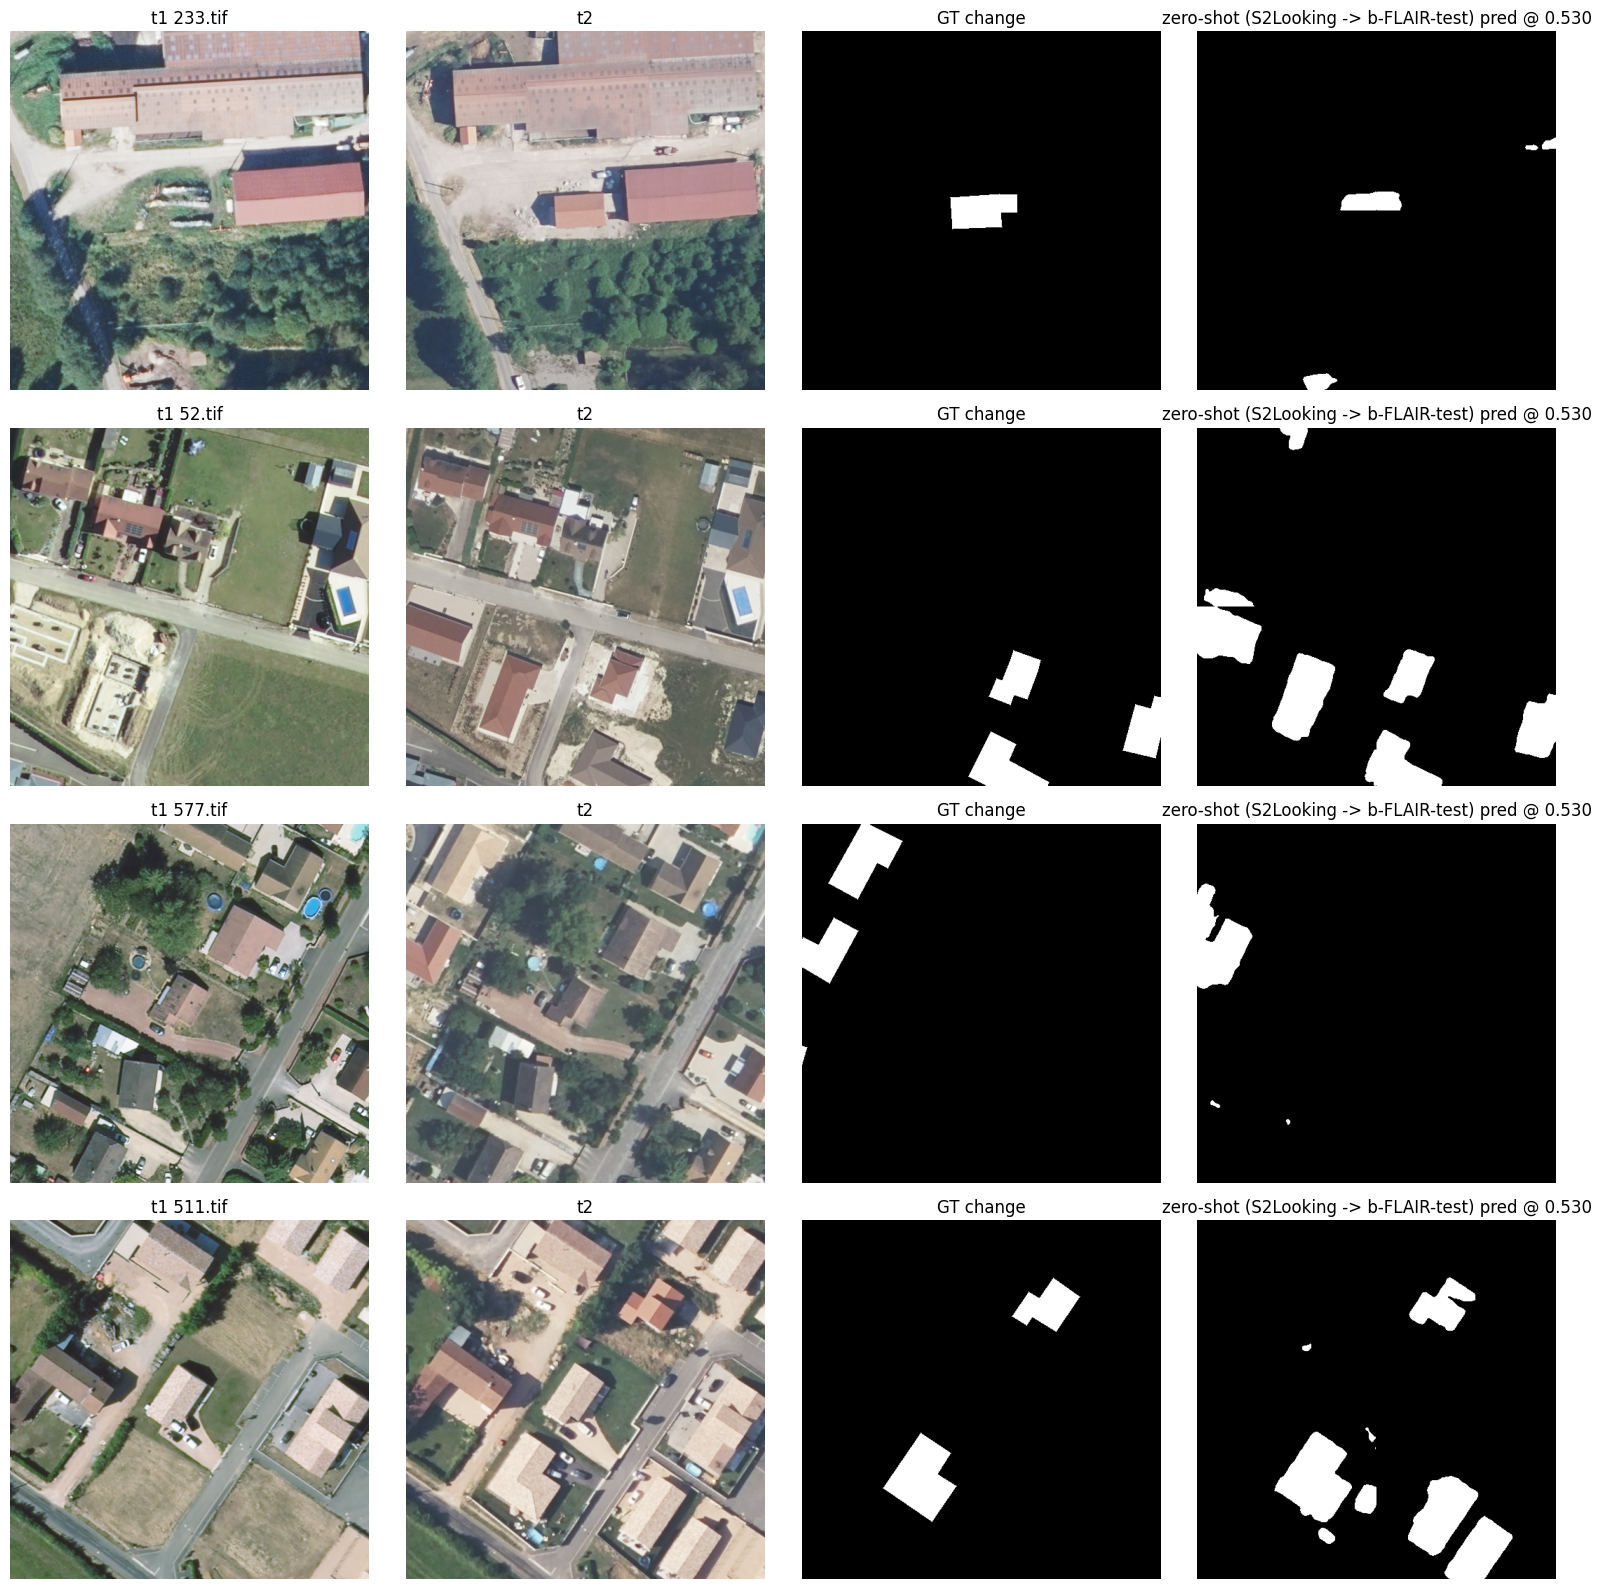


ZERO-SHOT INFERENCE COMPLETE


In [9]:
# ===================== QGMamba-CD: zero-shot inference on b-FLAIR-test (cell B) =====================
# Loads the S2Looking-trained checkpoint and evaluates it zero-shot over the
# FULL b-FLAIR-test set -- all pairs, no train/val/test split.
#
# Because nothing is held out, no threshold is selected here:
#
#   1. The HEADLINE number is the full-set metric at the checkpoint's own
#      stored threshold (the one chosen on S2Looking val).
#   2. A reference curve over 0.05..0.90 is reported so you can see where the
#      model's probabilities land on this domain. Every point on that curve
#      is in-sample; treat it as diagnostics, not as a selected operating
#      point.
#   3. The headline is repeated under the final protocol (stride 128).

import gc
import json

# ============================================================
# PRECONDITION CHECK
# ============================================================

_REQUIRED = [
    "build_qgmamba",
    "normalize_state_dict",
    "evaluate_threshold",
    "sweep_thresholds",
    "qg_show",
    "qg_full_ds",
    "QG_EVAL",
    "CONTEXT",
    "DEVICE",
    "OUT_DIR",
    "QG_CKPT_PATH",
    "BFLAIR_VERSION",
]

_missing = [x for x in _REQUIRED if x not in globals()]

if _missing:
    raise RuntimeError(
        "Run the zero-shot setup cell first.\n"
        f"Missing: {_missing}"
    )


# ============================================================
# LOAD CHECKPOINT
# ============================================================

TRAIN_DATASET = "S2Looking"
PROTOCOL = "zero_shot"

print("Checkpoint:", QG_CKPT_PATH)
print("Exists    :", QG_CKPT_PATH.exists())

qg_ckpt = torch.load(
    QG_CKPT_PATH,
    map_location="cpu",
    weights_only=False
)

if (
    not isinstance(qg_ckpt, dict)
    or not ({"model_state", "ema_state", "state_dict"} & set(qg_ckpt))
):
    qg_ckpt = {"model_state": qg_ckpt}

# The checkpoint records which weights produced its best number
# (eval_weights: 'ema' for this one); honour that rather than guessing.
use_ema = (
    qg_ckpt.get("eval_weights", "model") != "model"
    and "ema_state" in qg_ckpt
)

zs_state = qg_ckpt["ema_state"] if use_ema else qg_ckpt.get(
    "model_state", qg_ckpt.get("state_dict")
)

if zs_state is None:
    raise RuntimeError("No model_state/state_dict found in checkpoint.")

CKPT_THR = float(qg_ckpt.get("threshold", 0.5))

print("\n" + "=" * 70)
print("CHECKPOINT INFORMATION")
print("=" * 70)
print("checkpoint :", QG_CKPT_PATH.name)
print("epoch      :", qg_ckpt.get("epoch", "?"))
print(f"best_f1    : {float(qg_ckpt.get('best_f1', float('nan'))):.4f}"
      f"  best_iou: {float(qg_ckpt.get('best_iou', float('nan'))):.4f}")
print("weights    :", "ema" if use_ema else "model")
print(f"ckpt thresh: {CKPT_THR:.3f}  (selected on S2Looking val)")
print(f"protocol   : {PROTOCOL} (trained on {TRAIN_DATASET}, "
      f"evaluated on all {len(qg_full_ds)} b-FLAIR-test pairs)")


# ============================================================
# BUILD MODEL + LOAD WEIGHTS
# ============================================================

print("\nBuilding QGMamba model...")

zs_model = build_qgmamba(pretrained=False)

normalized_state = normalize_state_dict(zs_state)

load_result = zs_model.load_state_dict(normalized_state, strict=True)

print("Checkpoint loaded successfully")
print("Missing keys    :", len(load_result.missing_keys))
print("Unexpected keys :", len(load_result.unexpected_keys))

zs_model = zs_model.to(DEVICE).eval()
print("Model device:", next(zs_model.parameters()).device)

# The checkpoint also carries optimizer/scheduler/scaler/ema states (~500 MB);
# none of it is needed after the weights are in the model.
for k in ("optimizer", "scheduler", "optimizer_state", "scheduler_state",
          "scaler", "ema_state"):
    qg_ckpt.pop(k, None)

del zs_state, normalized_state
gc.collect()
torch.cuda.empty_cache()


# ============================================================
# AMP CONFIGURATION
# ============================================================

USE_AMP = torch.cuda.is_available()
AMP_DTYPE = "float16" if USE_AMP else "float32"


# ============================================================
# A. HEADLINE: FULL SET AT THE CHECKPOINT THRESHOLD (quick protocol)
# ============================================================

print("\n" + "=" * 70)
print(f"FULL SET @ CHECKPOINT THRESHOLD {CKPT_THR:.3f}  (quick protocol)")
print("=" * 70)

zs_at_ckpt_thr = evaluate_threshold(
    zs_model,
    qg_full_ds,
    CKPT_THR,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE,
    final=False
)

print(json.dumps(zs_at_ckpt_thr, indent=2))


# ============================================================
# B. REFERENCE THRESHOLD CURVE ON THE FULL SET
# ============================================================
# Same probability maps as above are recomputed here once by the sweep
# helper; the grid is evaluated for context only. With no held-out split the
# best-F1 point of this curve is NOT a legitimate operating-point choice.

print("\n" + "=" * 70)
print("REFERENCE THRESHOLD CURVE  (0.05 .. 0.90, full set, in-sample)")
print("=" * 70)

zs_curve_thr, zs_curve_best, zs_curve_table = sweep_thresholds(
    zs_model,
    qg_full_ds,
    QG_EVAL.thresholds,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE
)

print(f"\nhighest-F1 threshold on the curve: {zs_curve_thr:.3f} "
      "(reference only)")
print(json.dumps(zs_curve_best, indent=2))

try:
    print("\n", zs_curve_table.to_string(index=False))
except AttributeError:
    pass


# ============================================================
# C. FULL SET AT THE CHECKPOINT THRESHOLD -- FINAL PROTOCOL
# ============================================================

print("\n" + "=" * 70)
print(f"FULL SET @ CHECKPOINT THRESHOLD {CKPT_THR:.3f}  "
      "(final protocol, stride 128)")
print("=" * 70)

zs_at_ckpt_thr_final = evaluate_threshold(
    zs_model,
    qg_full_ds,
    CKPT_THR,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE,
    final=True
)

print(json.dumps(zs_at_ckpt_thr_final, indent=2))


# ============================================================
# REPORT + SAVE
# ============================================================

def _curve_records(table):
    try:
        return table.to_dict("records")
    except AttributeError:
        return None

report = {
    "checkpoint": str(QG_CKPT_PATH),
    "train_dataset": TRAIN_DATASET,
    "eval_dataset": "b-FLAIR-test",
    "version": BFLAIR_VERSION,
    "protocol": PROTOCOL,
    "split": "none -- all pairs evaluated",
    "pairs": len(qg_full_ds),
    "weights": "ema" if use_ema else "model",
    "epoch": qg_ckpt.get("epoch"),
    "ckpt_best_f1": qg_ckpt.get("best_f1"),
    "ckpt_best_iou": qg_ckpt.get("best_iou"),

    "headline_full_at_checkpoint_threshold": {
        "threshold": CKPT_THR,
        **zs_at_ckpt_thr
    },

    "headline_full_at_checkpoint_threshold_final_protocol": {
        "threshold": CKPT_THR,
        **zs_at_ckpt_thr_final
    },

    "reference_threshold_curve": {
        "note": "in-sample on the full set; diagnostics only, "
                "no threshold was selected on this data",
        "highest_f1_threshold": zs_curve_thr,
        "highest_f1_metrics": zs_curve_best,
        "curve": _curve_records(zs_curve_table),
    },
}

print("\n" + "=" * 70)
print("FINAL REPORT")
print("=" * 70)
print(json.dumps({k: v for k, v in report.items()
                  if k != "reference_threshold_curve"}, indent=2))

OUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUT_DIR / "qgmamba_bflair_zero_shot_metrics.json"

with open(output_path, "w") as handle:
    json.dump(report, handle, indent=2)

print("\nMetrics written to:", output_path)


# ============================================================
# VISUALIZE
# ============================================================

qg_show(
    zs_model,
    qg_full_ds,
    CKPT_THR,
    n=4,
    title=f"zero-shot ({TRAIN_DATASET} -> b-FLAIR-test)"
)


# ============================================================
# CLEANUP
# ============================================================

del zs_model
del qg_ckpt

gc.collect()
torch.cuda.empty_cache()

print("\nZERO-SHOT INFERENCE COMPLETE")
